Model training completed.


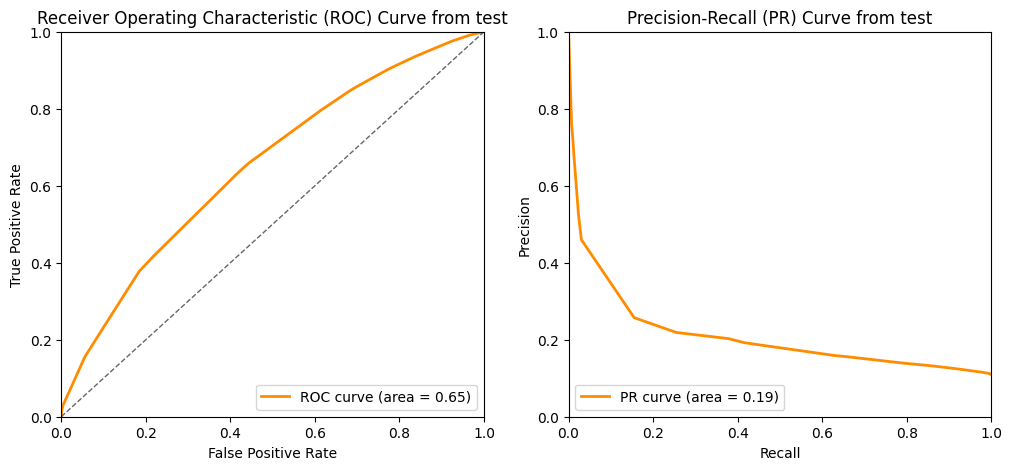

AUROC: 0.6505
AUPRC: 0.1879


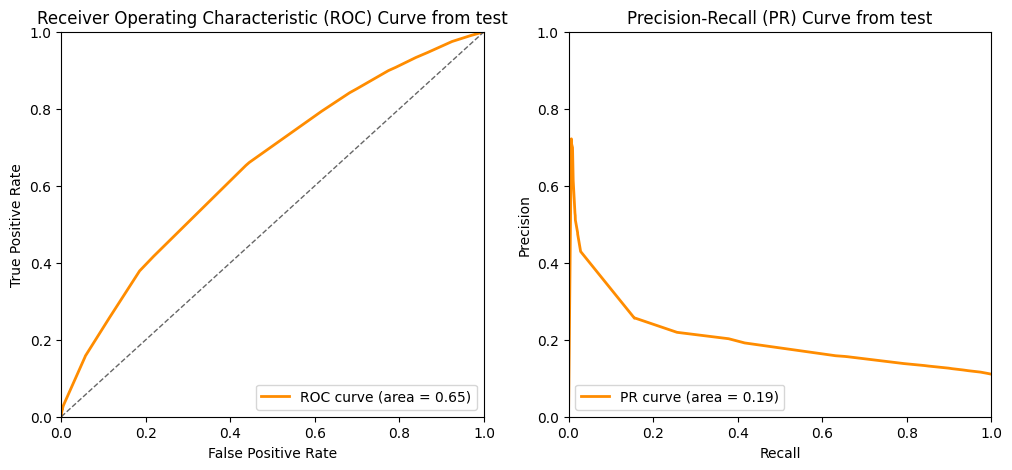

AUROC: 0.6487
AUPRC: 0.1852


In [2]:
## 训练单个模型，以用于优化
import ehr_utils
import ehr_models
file_path='data_cleaned/ver-noelectrolyte-logtransform_mean.csv'

X_train, X_test, Y_train, Y_test = ehr_utils.get_train_test(file_path, train_size=0.8, random_state=42)
model = ehr_models.init_decisionTree(False)
model.fit(X_train, Y_train)
print("Model training completed.")
Y_prob,Y_pred = ehr_utils.get_prediction_results(model, X_test)
Ytrain_prob,Ytrain_pred = ehr_utils.get_prediction_results(model, X_train)
ehr_utils.plot_roc_pr_curves(Y_train, Ytrain_prob, 'dt')
ehr_utils.plot_roc_pr_curves(Y_test, Y_prob, 'dt')
metrics=ehr_utils.eval_model(Y_test, Y_pred, Y_prob)



In [3]:
#可选是否替换之前已训练好的模型
ehr_models.save_model(model, 'DecisionTree','mean',auc=metrics[0])